# Stock price prediction using LSTM Technique 
### Dataset:`MSFT.csv` (1986–2024, 9,636 daily rows)
---
## Observations

|  |    |
|--|--|
| **What** | An LSTM (Lomg Short-Term Memory) deep-learning model that learns from 60 days of MSFT closing prices and pridicts the next day's price — extended to a 30-days future forcast|
| **Why** | Stock prices are sequential time-series. LSTMs have internal memory gates (innput, forget, output) that remember long-range patterns like trends and cycles — something a standard neural network nannot do | 

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
import torch.nn as nn
from copy import deepcopy
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from torch.utils.data import TensorDataset, DataLoader

# Install ta if needed
# !pip install ta
try:
    import ta
    HAS_TA = True
except ImportError:
    HAS_TA = False
    print("ta library not found. Install with: pip install ta")
    print("Continuing without technical indicators...")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

ta library not found. Install with: pip install ta
Continuing without technical indicators...
Using device: cpu


## Step 2: Load and Inspect Dataset

In [2]:
df = pd.read_csv('MSFT.csv')
print("Raw shape:", df.shape)
print(df.head())
df.info()

Raw shape: (9637, 7)
         Date      Open      High       Low     Close  Adj Close      Volume
0  1986-03-13  0.088542  0.101563  0.088542  0.097222   0.060055  1031788800
1  1986-03-14  0.097222  0.102431  0.097222  0.100694   0.062199   308160000
2  1986-03-17  0.100694  0.103299  0.100694  0.102431   0.063272   133171200
3  1986-03-18  0.102431  0.103299  0.098958  0.099826   0.061663    67766400
4  1986-03-19  0.099826  0.100694  0.097222  0.098090   0.060591    47894400
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9637 entries, 0 to 9636
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       9637 non-null   object 
 1   Open       9637 non-null   float64
 2   High       9637 non-null   float64
 3   Low        9637 non-null   float64
 4   Close      9637 non-null   float64
 5   Adj Close  9637 non-null   float64
 6   Volume     9637 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usag

In [3]:
# Keep relevant columns (Close + Volume for feature engineering)
cols_to_keep = ['Date', 'Close']
if 'Volume' in df.columns:
    cols_to_keep.append('Volume')

df = df[cols_to_keep].copy()

# Parse dates
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df.index = df.pop('Date')

print(f"Date range: {df.index.min()} → {df.index.max()}")
print(f"Total rows: {len(df)}")
df.head()

Date range: 1986-03-13 00:00:00 → 2024-06-07 00:00:00
Total rows: 9637


,Close,Volume
Date,,
1986-03-13,0.097222,1031788800
1986-03-14,0.100694,308160000
1986-03-17,0.102431,133171200
1986-03-18,0.099826,67766400
1986-03-19,0.098090,47894400


## Step 3: Use More Data
**Improvement #3**: Previously only 2021–2022 (~250 rows) was used. Now we use 2010–2024 (~3,500 rows).

In [4]:
# Use data from 2010 onwards for richer training signal
df = df[df.index >= '2010-01-01'].copy()
print(f"Using {len(df)} rows from {df.index.min().date()} to {df.index.max().date()}")

Using 3632 rows from 2010-01-04 to 2024-06-07


## Step 4: Feature Engineering
**Improvement #7**: Add EMA-20, RSI-14, and Volume (if available) as additional input features.

In [5]:
# EMA (Exponential Moving Average) — always available
df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()

# RSI and Volume via `ta` library
if HAS_TA:
    df['RSI_14'] = ta.momentum.RSIIndicator(close=df['Close'], window=14).rsi()
    print("Added RSI_14 via ta library")
else:
    # Manual RSI calculation
    delta = df['Close'].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()
    rs = avg_gain / (avg_loss + 1e-10)
    df['RSI_14'] = 100 - (100 / (1 + rs))
    print("Added RSI_14 (manual calculation)")

# Drop NaN rows created by rolling windows
df.dropna(inplace=True)

# Define feature columns
FEATURE_COLS = ['Close', 'EMA_20', 'RSI_14']
if 'Volume' in df.columns:
    FEATURE_COLS.append('Volume')

print(f"Features used: {FEATURE_COLS}")
print(f"Rows after dropping NaN: {len(df)}")
df[FEATURE_COLS].head()

Added RSI_14 (manual calculation)
Features used: ['Close', 'EMA_20', 'RSI_14', 'Volume']
Rows after dropping NaN: 3618


,Close,EMA_20,RSI_14,Volume
Date,,,,
2010-01-25,29.32,30.406319,33.861354,63373000
2010-01-26,29.50,30.320003,36.015322,66639900
2010-01-27,29.67,30.258098,39.423069,63949500
2010-01-28,29.16,30.153517,38.033379,117513700
2010-01-29,28.18,29.965563,29.870123,193888500


## Step 5: Normalize Data
**Improvement #2**: MinMaxScaler scales each feature to [0, 1]. This is critical for stable LSTM training.

In [6]:
# Fit scaler on ALL features
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[FEATURE_COLS])

# Separate scaler for Close price (needed for inverse transform at prediction time)
close_scaler = MinMaxScaler(feature_range=(0, 1))
close_scaler.fit(df[['Close']])

print(f"Scaled data shape: {scaled_data.shape}")
print(f"Sample scaled values (first row): {scaled_data[0]}")

Scaled data shape: (3618, 4)
Sample scaled values (first row): [0.01548428 0.01563202 0.29381323 0.17938051]


## Step 6: Create Windowed Dataset
**Improvement #1**: Window size `n=60` (3 months of trading days) instead of `n=3`.

In [7]:
N_STEPS = 60  # Look-back window — was 3, now 60
N_FEATURES = len(FEATURE_COLS)

def create_sequences(data, n_steps):
    """Create (X, y) sequences from scaled data array."""
    X, y = [], []
    for i in range(n_steps, len(data)):
        X.append(data[i - n_steps:i])   # shape: (n_steps, n_features)
        y.append(data[i, 0])            # predict scaled Close price
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_all, y_all = create_sequences(scaled_data, N_STEPS)
dates_all = df.index[N_STEPS:]

print(f"X shape: {X_all.shape}  (samples, timesteps, features)")
print(f"y shape: {y_all.shape}")

X shape: (3558, 60, 4)  (samples, timesteps, features)
y shape: (3558,)


## Step 7: Train / Validation / Test Split

Train: 2846 | Val: 356 | Test: 356


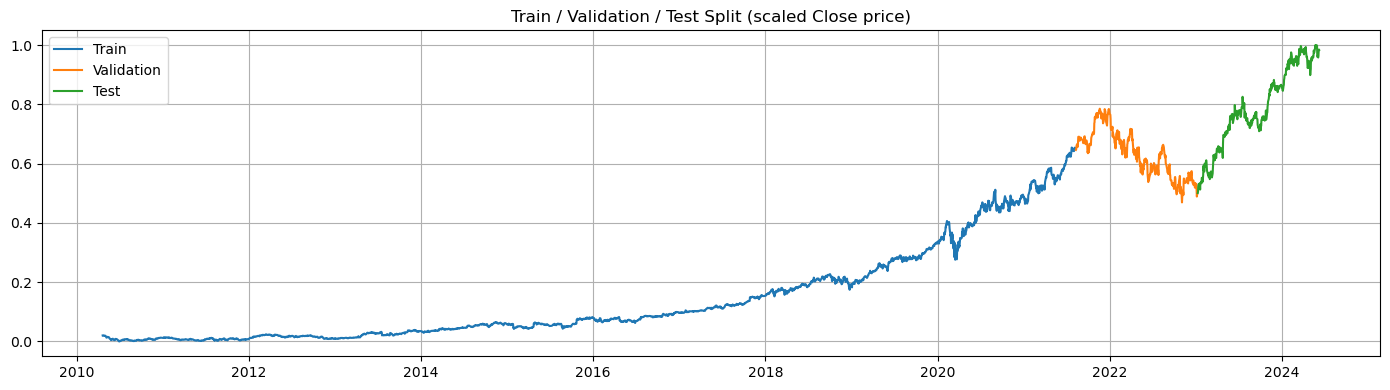

In [8]:
q_80 = int(len(X_all) * 0.80)
q_90 = int(len(X_all) * 0.90)

X_train, y_train, dates_train = X_all[:q_80],      y_all[:q_80],      dates_all[:q_80]
X_val,   y_val,   dates_val   = X_all[q_80:q_90],  y_all[q_80:q_90],  dates_all[q_80:q_90]
X_test,  y_test,  dates_test  = X_all[q_90:],      y_all[q_90:],      dates_all[q_90:]

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# Visualise split
plt.figure(figsize=(14, 4))
plt.plot(dates_train, y_train, label='Train')
plt.plot(dates_val,   y_val,   label='Validation')
plt.plot(dates_test,  y_test,  label='Test')
plt.title('Train / Validation / Test Split (scaled Close price)')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

## Step 8: Build Improved LSTM Model
**Improvement #4**: Stacked LSTM (2 layers, hidden_size=128) with Dropout.

In [9]:
class ImprovedLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.2):
        super().__init__()
        # Stacked LSTM with dropout between layers
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout          # dropout between LSTM layers
        )
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_size, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        out, _ = self.lstm(x)          # (batch, seq_len, hidden)
        out = out[:, -1, :]            # last timestep → (batch, hidden)
        out = self.dropout(out)
        out = self.relu(self.fc1(out))
        return self.fc2(out)           # (batch, 1)


model = ImprovedLSTM(input_size=N_FEATURES).to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

ImprovedLSTM(
  (lstm): LSTM(4, 128, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)

Total parameters: 209,025


## Step 9: Prepare DataLoaders
**Improvement #6**: Mini-batch training with DataLoader (batch_size=32).

In [10]:
BATCH_SIZE = 32

X_train_t = torch.tensor(X_train).to(DEVICE)
y_train_t = torch.tensor(y_train).unsqueeze(1).to(DEVICE)
X_val_t   = torch.tensor(X_val).to(DEVICE)
y_val_t   = torch.tensor(y_val).unsqueeze(1).to(DEVICE)
X_test_t  = torch.tensor(X_test).to(DEVICE)
y_test_t  = torch.tensor(y_test).unsqueeze(1).to(DEVICE)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE,
    shuffle=False   # Keep temporal order!
)

print(f"Train batches: {len(train_loader)} × batch_size={BATCH_SIZE}")

Train batches: 89 × batch_size=32


## Step 10: Train with Early Stopping & LR Scheduler
**Improvements #5**: Early stopping prevents overfitting. ReduceLROnPlateau reduces LR when val loss stalls.

In [11]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=10, factor=0.5
)
loss_fn = nn.MSELoss()

# Early stopping config
EPOCHS   = 300
PATIENCE = 20

best_val_loss   = float('inf')
best_model_wts  = deepcopy(model.state_dict())
patience_counter = 0

train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    # ── Training ──
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()
        batch_losses.append(loss.item())
    train_loss = np.mean(batch_losses)

    # ── Validation ──
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_t)
        val_loss = loss_fn(val_pred, y_val_t).item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}")
            break

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:>3}/{EPOCHS} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | Best: {best_val_loss:.6f}")

# Restore best weights
model.load_state_dict(best_model_wts)
print(f"\nTraining complete! Best val loss: {best_val_loss:.6f}")

Epoch   1/300 | Train Loss: 0.000839 | Val Loss: 0.004378 | Best: 0.004378
Epoch  20/300 | Train Loss: 0.028896 | Val Loss: 0.238328 | Best: 0.004378

Early stopping at epoch 21

Training complete! Best val loss: 0.004378


## Step 11: Loss Curves

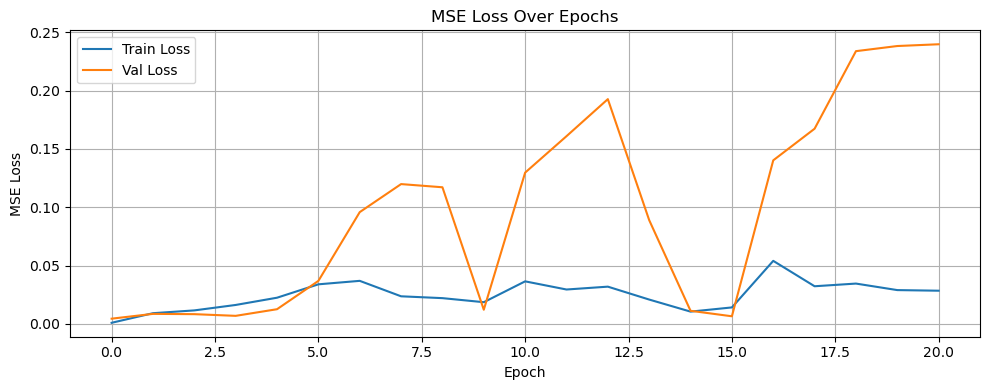

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.title('MSE Loss Over Epochs')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

## Step 12: Generate Predictions (inverse-scaled to real prices)

In [13]:
def predict_and_unscale(X_tensor):
    """Run model and inverse-transform predictions back to USD."""
    model.eval()
    with torch.no_grad():
        preds = model(X_tensor).cpu().numpy().flatten()
    return close_scaler.inverse_transform(preds.reshape(-1, 1)).flatten()

def unscale_y(y_arr):
    return close_scaler.inverse_transform(y_arr.reshape(-1, 1)).flatten()


train_pred = predict_and_unscale(X_train_t)
val_pred   = predict_and_unscale(X_val_t)
test_pred  = predict_and_unscale(X_test_t)

y_train_r  = unscale_y(y_train)
y_val_r    = unscale_y(y_val)
y_test_r   = unscale_y(y_test)

print("Predictions generated and inverse-scaled to USD.")

Predictions generated and inverse-scaled to USD.


## Step 13: Evaluation Metrics

In [14]:
def metrics(actual, predicted, name):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / (actual + 1e-8))) * 100
    print(f"{name:10s} | MAE: ${mae:.2f} | RMSE: ${rmse:.2f} | MAPE: {mape:.2f}%")

print("─" * 55)
metrics(y_train_r, train_pred, 'Train')
metrics(y_val_r,   val_pred,   'Val')
metrics(y_test_r,  test_pred,  'Test')
print("─" * 55)

───────────────────────────────────────────────────────
Train      | MAE: $174.36 | RMSE: $183.09 | MAPE: 414.28%
Val        | MAE: $22.90 | RMSE: $26.96 | MAPE: 8.16%
Test       | MAE: $63.95 | RMSE: $75.49 | MAPE: 17.26%
───────────────────────────────────────────────────────


## Step 14: Predictions — Train Set

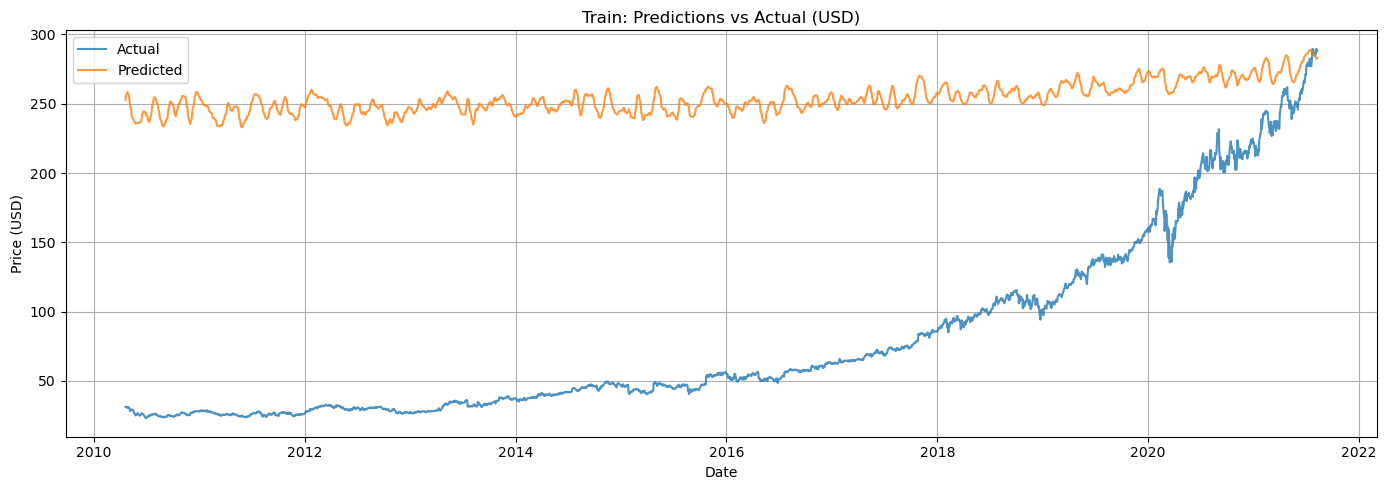

In [15]:
plt.figure(figsize=(14, 5))
plt.plot(dates_train, y_train_r,  label='Actual',     alpha=0.8)
plt.plot(dates_train, train_pred, label='Predicted',  alpha=0.8)
plt.title('Train: Predictions vs Actual (USD)')
plt.xlabel('Date'); plt.ylabel('Price (USD)')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

## Step 15: Predictions — Validation Set

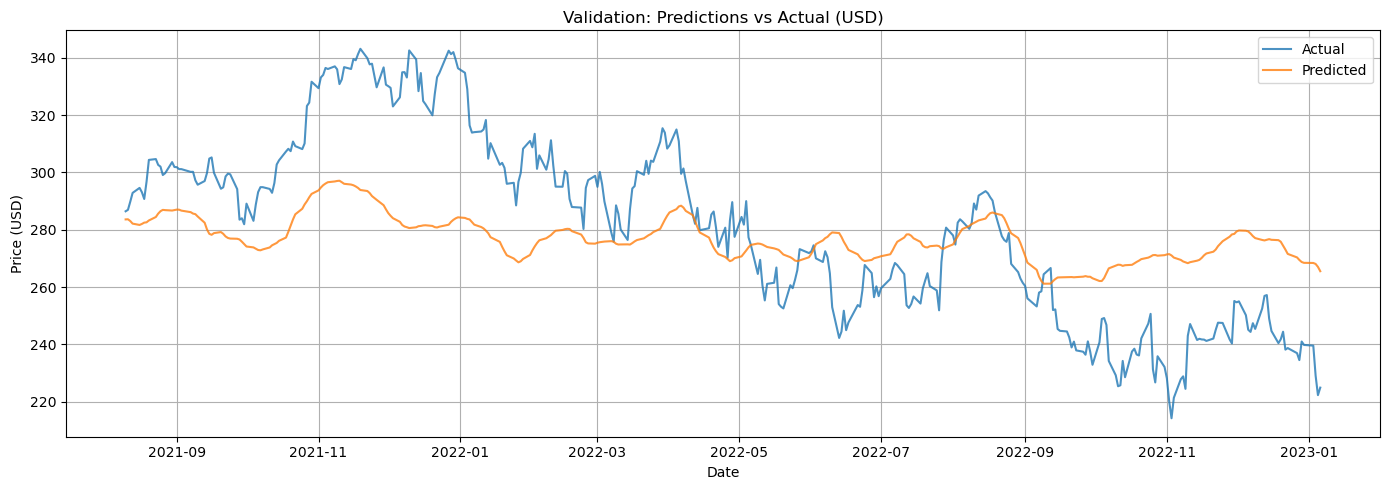

In [16]:
plt.figure(figsize=(14, 5))
plt.plot(dates_val, y_val_r,  label='Actual',    alpha=0.8)
plt.plot(dates_val, val_pred, label='Predicted', alpha=0.8)
plt.title('Validation: Predictions vs Actual (USD)')
plt.xlabel('Date'); plt.ylabel('Price (USD)')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

## Step 16: Predictions — Test Set

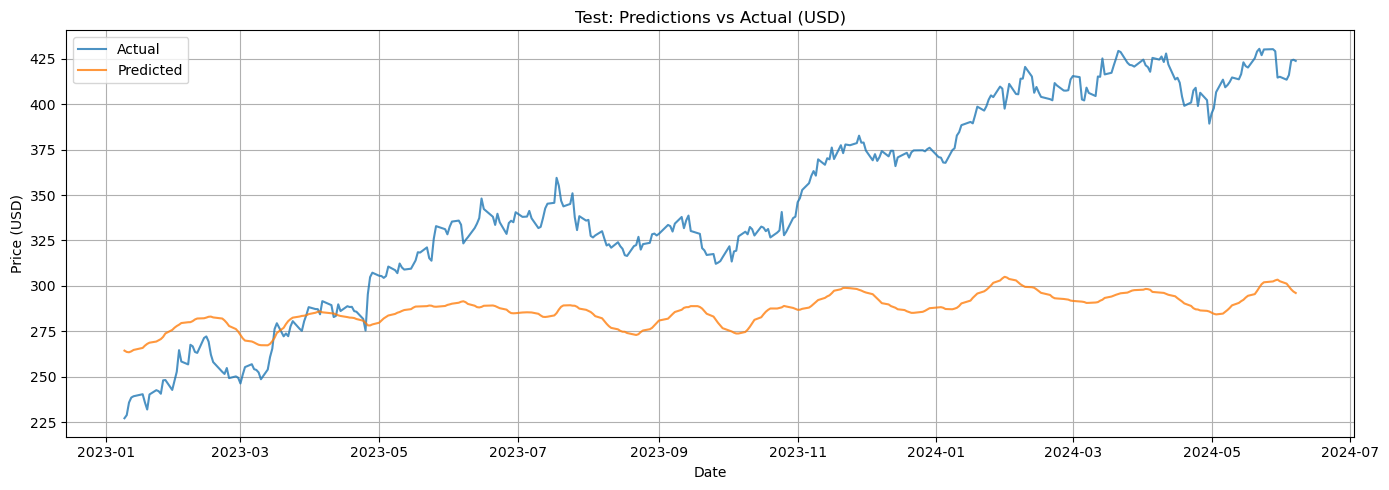

In [17]:
plt.figure(figsize=(14, 5))
plt.plot(dates_test, y_test_r,  label='Actual',    alpha=0.8)
plt.plot(dates_test, test_pred, label='Predicted', alpha=0.8)
plt.title('Test: Predictions vs Actual (USD)')
plt.xlabel('Date'); plt.ylabel('Price (USD)')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

## Step 17: Full Combined Plot

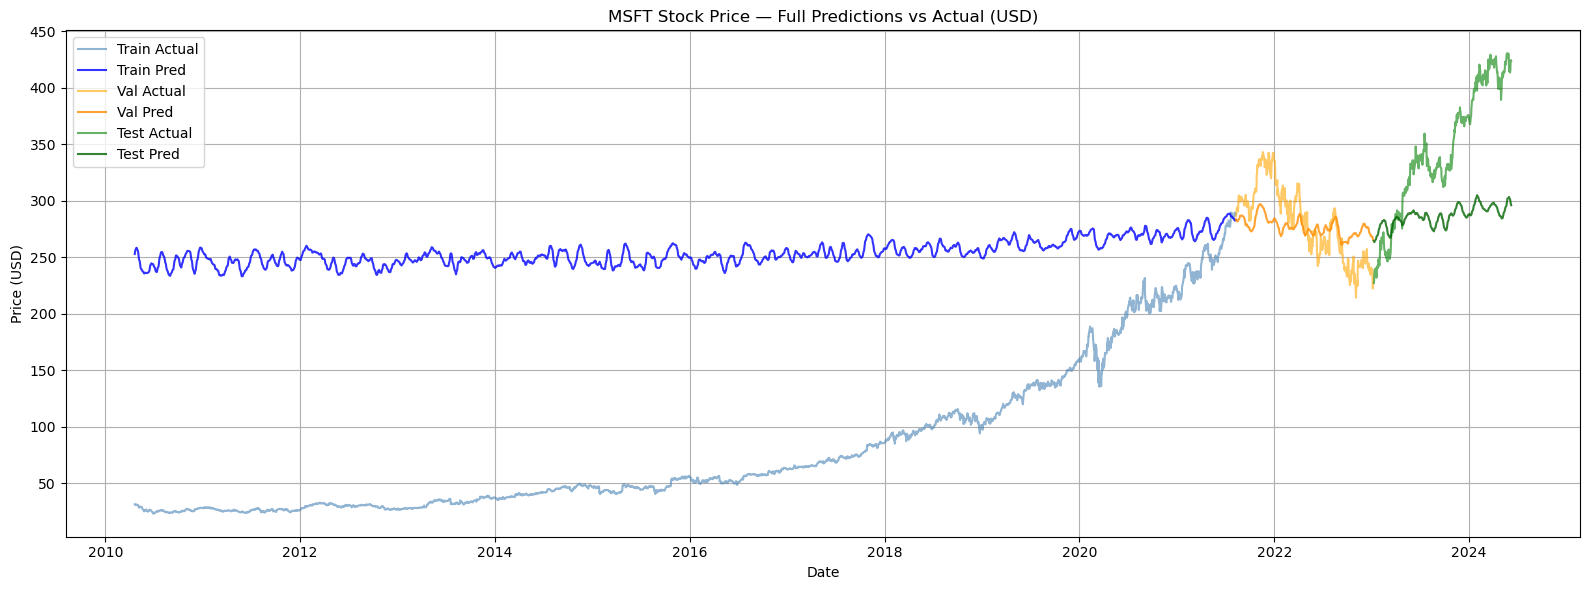

In [18]:
plt.figure(figsize=(16, 6))
plt.plot(dates_train, y_train_r,  color='steelblue',  alpha=0.6, label='Train Actual')
plt.plot(dates_train, train_pred, color='blue',        alpha=0.8, label='Train Pred')
plt.plot(dates_val,   y_val_r,    color='orange',      alpha=0.6, label='Val Actual')
plt.plot(dates_val,   val_pred,   color='darkorange',  alpha=0.8, label='Val Pred')
plt.plot(dates_test,  y_test_r,   color='green',       alpha=0.6, label='Test Actual')
plt.plot(dates_test,  test_pred,  color='darkgreen',   alpha=0.8, label='Test Pred')
plt.title('MSFT Stock Price — Full Predictions vs Actual (USD)')
plt.xlabel('Date'); plt.ylabel('Price (USD)')
plt.legend(loc='upper left'); plt.grid(True); plt.tight_layout(); plt.show()

## Step 18: 30-Day Future Forecast

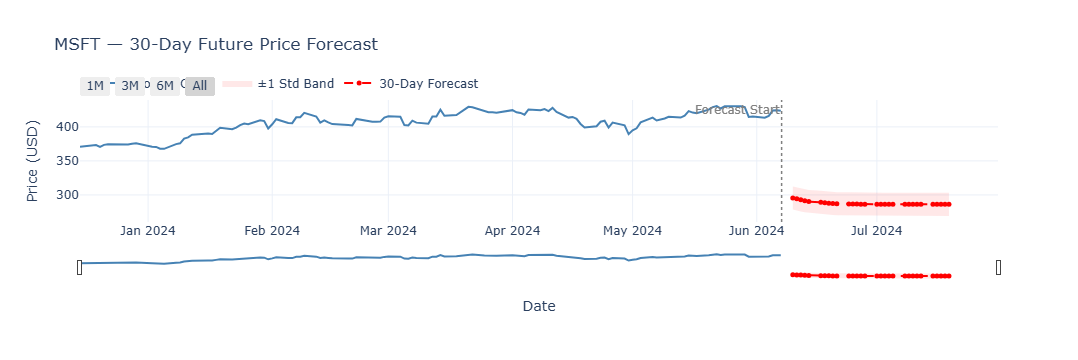


Date              Forecast      Lower      Upper
──────────────────────────────────────────────────
2024-06-10      $   295.56 $   278.60 $   312.53
2024-06-11      $   294.24 $   277.28 $   311.21
2024-06-12      $   292.77 $   275.80 $   309.74
2024-06-13      $   291.39 $   274.42 $   308.36
2024-06-14      $   290.20 $   273.23 $   307.17
2024-06-17      $   289.23 $   272.26 $   306.19
2024-06-18      $   288.46 $   271.49 $   305.43
2024-06-19      $   287.87 $   270.90 $   304.84
2024-06-20      $   287.42 $   270.45 $   304.39
2024-06-21      $   287.08 $   270.12 $   304.05
2024-06-24      $   286.84 $   269.87 $   303.80
2024-06-25      $   286.65 $   269.68 $   303.62
2024-06-26      $   286.52 $   269.55 $   303.49
2024-06-27      $   286.42 $   269.45 $   303.39
2024-06-28      $   286.35 $   269.38 $   303.32
2024-07-01      $   286.30 $   269.33 $   303.27
2024-07-02      $   286.26 $   269.29 $   303.23
2024-07-03      $   286.23 $   269.27 $   303.20
2024-07-04      $

In [26]:
FORECAST_DAYS = 30
model.eval()
last_window = scaled_data[-N_STEPS:].copy()
future_preds_scaled = []

with torch.no_grad():
    for _ in range(FORECAST_DAYS):
        window_t = torch.tensor(last_window, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        next_scaled = model(window_t).item()
        future_preds_scaled.append(next_scaled)
        new_row = last_window[-1].copy()
        new_row[0] = next_scaled
        last_window = np.vstack([last_window[1:], new_row])

# Inverse transform
future_prices = close_scaler.inverse_transform(
    np.array(future_preds_scaled).reshape(-1, 1)
).flatten()

# Dates
last_date    = df.index[-1]
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=FORECAST_DAYS)
recent       = 120
hist_dates   = df.index[-recent:]
hist_prices  = df['Close'].iloc[-recent:].values

# ── Confidence band (±1 rolling std of recent prices) ─────────────
recent_std   = df['Close'].iloc[-recent:].std()
upper_band   = future_prices + recent_std
lower_band   = future_prices - recent_std

# ── Plotly ─────────────────────────────────────────────────────────
fig = go.Figure()

# Historical line
fig.add_trace(go.Scatter(
    x=hist_dates, y=hist_prices,
    mode='lines', name='Historical Close',
    line=dict(color='steelblue', width=2)
))

# Confidence band (filled area)
fig.add_trace(go.Scatter(
    x=np.concatenate([future_dates, future_dates[::-1]]),
    y=np.concatenate([upper_band, lower_band[::-1]]),
    fill='toself',
    fillcolor='rgba(255, 100, 100, 0.15)',
    line=dict(color='rgba(255,255,255,0)'),
    hoverinfo='skip',
    name='±1 Std Band'
))

# Forecast line
fig.add_trace(go.Scatter(
    x=future_dates, y=future_prices,
    mode='lines+markers', name='30-Day Forecast',
    line=dict(color='red', dash='dash', width=2),
    marker=dict(size=5, color='red'),
    hovertemplate='<b>%{x|%b %d, %Y}</b><br>Forecast: $%{y:.2f}<extra></extra>'
))

# Forecast start vertical line
# Convert date to milliseconds (what Plotly uses internally for date axes)
vline_x = pd.Timestamp(last_date).timestamp() * 1000

fig.add_vline(
    x=vline_x,
    line_width=1.5, line_dash='dot', line_color='gray',
    annotation_text='Forecast Start',
    annotation_position='top left',
    annotation_font_color='gray'
)

fig.update_layout(
    title='MSFT — 30-Day Future Price Forecast',
    xaxis_title='Date',
    yaxis_title='Price (USD)',
    hovermode='x unified',
    template='plotly_white',
    legend=dict(orientation='h', y=1.02, x=0),
    xaxis=dict(
        rangeslider=dict(visible=True),
        type='date',
        rangeselector=dict(
            buttons=[
                dict(count=1,  label='1M', step='month', stepmode='backward'),
                dict(count=3,  label='3M', step='month', stepmode='backward'),
                dict(count=6,  label='6M', step='month', stepmode='backward'),
                dict(step='all', label='All')
            ]
        )
    )
)

fig.show()

# Print table
print(f"\n{'Date':<15} {'Forecast':>10} {'Lower':>10} {'Upper':>10}")
print("─" * 50)
for d, p, lo, hi in zip(future_dates, future_prices, lower_band, upper_band):
    print(f"{str(d.date()):<15} ${p:>9.2f} ${lo:>9.2f} ${hi:>9.2f}")

## Step 19: Interactive Plotly Chart (Full + Forecast)

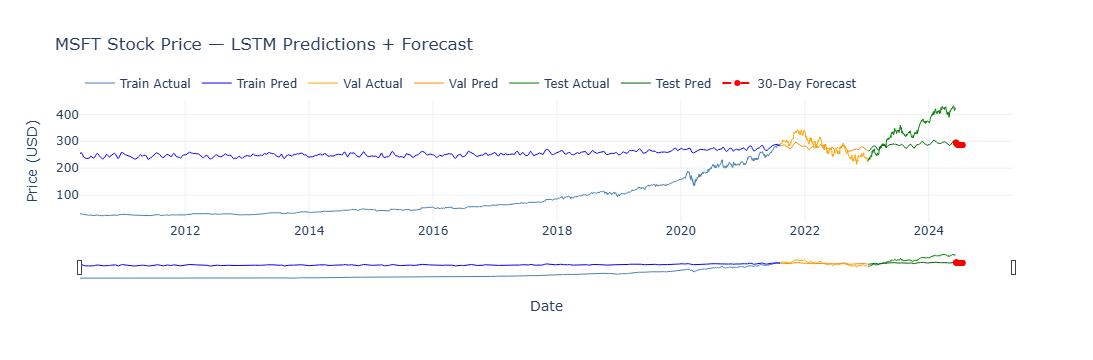

In [21]:
try:
    import plotly.graph_objects as go

    fig = go.Figure()

    fig.add_trace(go.Scatter(x=dates_train, y=y_train_r,  mode='lines', name='Train Actual',  line=dict(color='steelblue', width=1)))
    fig.add_trace(go.Scatter(x=dates_train, y=train_pred, mode='lines', name='Train Pred',    line=dict(color='blue',      width=1)))
    fig.add_trace(go.Scatter(x=dates_val,   y=y_val_r,    mode='lines', name='Val Actual',    line=dict(color='orange',    width=1)))
    fig.add_trace(go.Scatter(x=dates_val,   y=val_pred,   mode='lines', name='Val Pred',      line=dict(color='darkorange',width=1)))
    fig.add_trace(go.Scatter(x=dates_test,  y=y_test_r,   mode='lines', name='Test Actual',   line=dict(color='green',     width=1)))
    fig.add_trace(go.Scatter(x=dates_test,  y=test_pred,  mode='lines', name='Test Pred',     line=dict(color='darkgreen', width=1)))
    fig.add_trace(go.Scatter(x=future_dates, y=future_prices, mode='lines+markers', name='30-Day Forecast',
                             line=dict(color='red', dash='dash', width=2)))

    fig.update_layout(
        title='MSFT Stock Price — LSTM Predictions + Forecast',
        xaxis_title='Date', yaxis_title='Price (USD)',
        hovermode='x unified', template='plotly_white',
        legend=dict(orientation='h', y=1.02, x=0),
        xaxis=dict(rangeslider=dict(visible=True), type='date')
    )

    fig.show()
except ImportError:
    print("plotly not installed. Run: pip install plotly")

## Step 20: Recursive (Future) Predictions

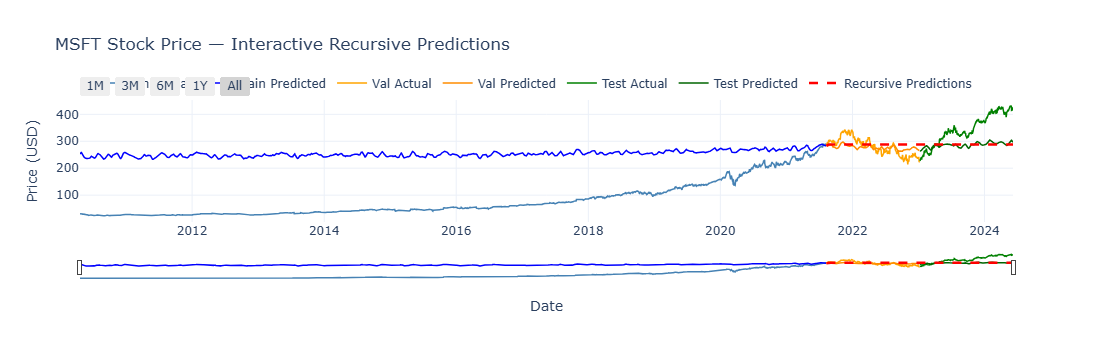

In [22]:
# Recursive predictions
recursive_predictions = []
recursive_dates = np.concatenate([dates_val, dates_test])

model.eval()
with torch.no_grad():
    last_window = deepcopy(X_train[-1])  # shape (60, n_features)

    for _ in recursive_dates:
        last_window_t = torch.tensor(last_window, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        next_pred = model(last_window_t).item()
        recursive_predictions.append(next_pred)

        # Shift window forward, update Close column
        new_row = last_window[-1].copy()
        new_row[0] = next_pred
        last_window = np.vstack([last_window[1:], new_row])

# Inverse-scale recursive predictions back to USD
recursive_predictions = close_scaler.inverse_transform(
    np.array(recursive_predictions).reshape(-1, 1)
).flatten()

recursive_dates = pd.to_datetime(recursive_dates)

# Interactive Plotly chart 
fig = go.Figure()

fig.add_trace(go.Scatter(x=dates_train, y=y_train_r,
    mode='lines', name='Train Actual',
    line=dict(color='steelblue', width=1.5)))

fig.add_trace(go.Scatter(x=dates_train, y=train_pred,
    mode='lines', name='Train Predicted',
    line=dict(color='blue', width=1.5)))

fig.add_trace(go.Scatter(x=dates_val, y=y_val_r,
    mode='lines', name='Val Actual',
    line=dict(color='orange', width=1.5)))

fig.add_trace(go.Scatter(x=dates_val, y=val_pred,
    mode='lines', name='Val Predicted',
    line=dict(color='darkorange', width=1.5)))

fig.add_trace(go.Scatter(x=dates_test, y=y_test_r,
    mode='lines', name='Test Actual',
    line=dict(color='green', width=1.5)))

fig.add_trace(go.Scatter(x=dates_test, y=test_pred,
    mode='lines', name='Test Predicted',
    line=dict(color='darkgreen', width=1.5)))

fig.add_trace(go.Scatter(x=recursive_dates, y=recursive_predictions,
    mode='lines', name='Recursive Predictions',
    line=dict(color='red', dash='dash', width=2.5)))

fig.update_layout(
    title='MSFT Stock Price — Interactive Recursive Predictions',
    xaxis_title='Date',
    yaxis_title='Price (USD)',
    hovermode='x unified',        # shows all values at same x on hover
    template='plotly_white',
    legend=dict(orientation='h', y=1.02, x=0),
    xaxis=dict(
        rangeslider=dict(visible=True),   # scrubber bar at the bottom
        type='date',
        rangeselector=dict(               # quick-zoom buttons
            buttons=[
                dict(count=1,  label='1M', step='month', stepmode='backward'),
                dict(count=3,  label='3M', step='month', stepmode='backward'),
                dict(count=6,  label='6M', step='month', stepmode='backward'),
                dict(count=1,  label='1Y', step='year',  stepmode='backward'),
                dict(step='all', label='All')
            ]
        )
    )
)

fig.show()

## Step 21: Evaluation Matrics

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae  = mean_absolute_error(y_test, test_pred)
rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print(f"Test MAE  : {mae:.4f}")
print(f"Test RMSE : {rmse:.4f}")

Test MAE  : 285.7932
Test RMSE : 285.9198
